<a href="https://colab.research.google.com/github/andrebrandaopro/Lista2/blob/Portf%C3%B3lio/q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Espirais em 3D: Comparação de Modelos e Análise de Correlação

Este notebook gera duas espirais 3D, aplica ruído, treina diversos classificadores (SVM linear, SVM RBF, MLP, Gaussian Process com RBF, Ensemble) e compara os resultados por acurácia, matriz de confusão e **matriz de correlação das predições**. Visualiza ainda as fronteiras de decisão em 2D (PCA).

In [1]:
# Imports principais
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns

## Funções utilitárias

In [2]:
def generate_spirals(n_points=1000, seed=42):
    np.random.seed(seed)
    theta = np.linspace(0, 20, n_points)
    noise = np.random.normal(scale=0.2, size=(n_points, 2))
    x1 = (theta / 4) * np.cos(theta) + noise[:, 0]
    y1 = (theta / 4) * np.sin(theta) + noise[:, 1]
    z1 = np.sin(theta) + np.random.normal(scale=0.1, size=theta.shape)
    x2 = ((theta / 4) + 0.8) * np.cos(theta) + noise[:, 0]
    y2 = ((theta / 4) + 0.8) * np.sin(theta) + noise[:, 1]
    z2 = np.cos(theta) + np.random.normal(scale=0.1, size=theta.shape)
    X = np.vstack([np.column_stack([x1, y1, z1]), np.column_stack([x2, y2, z2])])
    y = np.array([0]*n_points + [1]*n_points)
    return X, y

def plot_2d(X, y):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[y==0][:,0], X[y==0][:,1], s=10, label='Espiral 1')
    plt.scatter(X[y==1][:,0], X[y==1][:,1], s=10, label='Espiral 2')
    plt.title('Espirais com ruído (2D)')
    plt.legend()
    plt.show()

def plot_3d(X, y):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[y==0][:,0], X[y==0][:,1], X[y==0][:,2], c='b', s=8, label='Espiral 1')
    ax.scatter(X[y==1][:,0], X[y==1][:,1], X[y==1][:,2], c='r', s=8, label='Espiral 2')
    ax.set_title('Espirais com ruído (3D)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()

def train_and_evaluate(model, X_train, X_test, y_train, y_test, name='Model'):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'\n{name} - Acurácia: {acc:.3f}')
    print('Matriz de confusão:\n', confusion_matrix(y_test, y_pred))
    print('Classification Report:\n', classification_report(y_test, y_pred, digits=3))
    return model, y_pred

def plot_decision_boundary(clf, X, y, ax, title=""):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=10)
    ax.set_title(title)

def correlation_analysis(preds_dict):
    df_preds = pd.DataFrame(preds_dict)
    corr_matrix = df_preds.corr()
    print("\nMatriz de correlação entre as predições dos modelos:")
    print(corr_matrix)
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1)
    plt.title('Correlação entre predições dos classificadores')
    plt.show()

## Geração e visualização dos dados

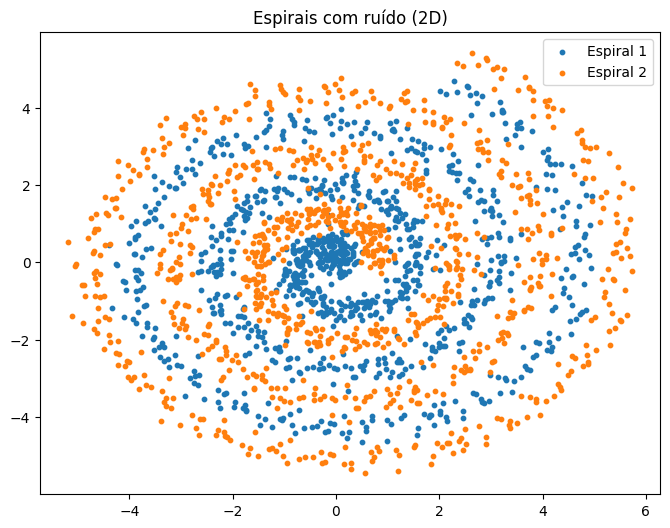

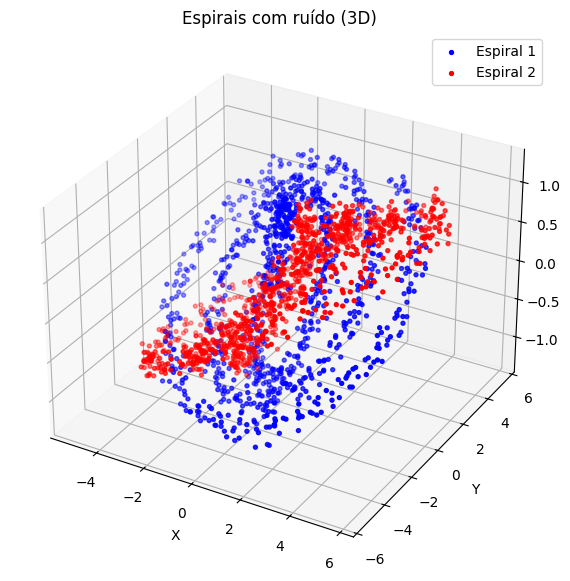

In [3]:
X, y = generate_spirals()
plot_2d(X, y)
plot_3d(X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Treinamento e avaliação dos classificadores

In [4]:
# Instanciando modelos
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_rbf = SVC(kernel='rbf', gamma='scale', probability=True, random_state=42)
mlp = MLPClassifier(hidden_layer_sizes=(40,), max_iter=2000, random_state=42)
rbf = GaussianProcessClassifier(1.0 * RBF(length_scale=1.0), random_state=42)
committee = VotingClassifier(estimators=[
    ('mlp', mlp),
    ('rbf', rbf),
    ('svm', svm_rbf)
], voting='soft')

# Treinamento e avaliação
_, y_pred_linear = train_and_evaluate(svm_linear, X_train, X_test, y_train, y_test, "SVM Linear")
_, y_pred_rbf = train_and_evaluate(svm_rbf, X_train, X_test, y_train, y_test, "SVM RBF")
_, y_pred_mlp = train_and_evaluate(mlp, X_train, X_test, y_train, y_test, "MLP")
_, y_pred_rbfnet = train_and_evaluate(rbf, X_train, X_test, y_train, y_test, "RBF (GaussianProcess)")
_, y_pred_committee = train_and_evaluate(committee, X_train, X_test, y_train, y_test, "Comitê (Ensemble)")


SVM Linear - Acurácia: 0.623
Matriz de confusão:
 [[262  40]
 [186 112]]
Classification Report:
               precision    recall  f1-score   support

           0      0.585     0.868     0.699       302
           1      0.737     0.376     0.498       298

    accuracy                          0.623       600
   macro avg      0.661     0.622     0.598       600
weighted avg      0.660     0.623     0.599       600


SVM RBF - Acurácia: 0.925
Matriz de confusão:
 [[287  15]
 [ 30 268]]
Classification Report:
               precision    recall  f1-score   support

           0      0.905     0.950     0.927       302
           1      0.947     0.899     0.923       298

    accuracy                          0.925       600
   macro avg      0.926     0.925     0.925       600
weighted avg      0.926     0.925     0.925       600


MLP - Acurácia: 0.968
Matriz de confusão:
 [[291  11]
 [  8 290]]
Classification Report:
               precision    recall  f1-score   support

       

## Comparação das predições: Matriz de Correlação


Matriz de correlação entre as predições dos modelos:
                       SVM Linear   SVM RBF       MLP  RBF (GaussianProcess)  \
SVM Linear               1.000000  0.355477  0.273973               0.281752   
SVM RBF                  0.355477  1.000000  0.861578               0.854182   
MLP                      0.273973  0.861578  1.000000               0.933419   
RBF (GaussianProcess)    0.281752  0.854182  0.933419               1.000000   
Ensemble                 0.294979  0.879389  0.963465               0.963774   

                       Ensemble  
SVM Linear             0.294979  
SVM RBF                0.879389  
MLP                    0.963465  
RBF (GaussianProcess)  0.963774  
Ensemble               1.000000  


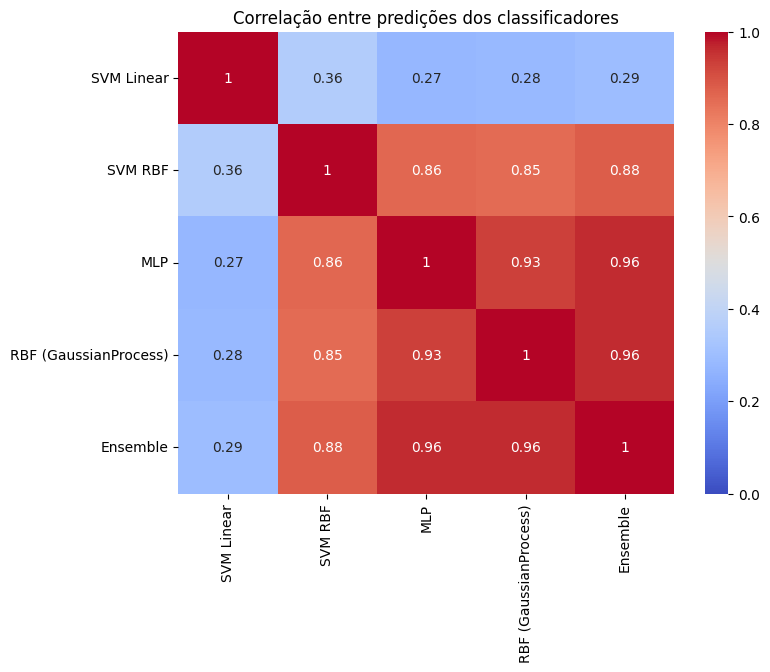

In [5]:
model_preds = {
    'SVM Linear': y_pred_linear,
    'SVM RBF': y_pred_rbf,
    'MLP': y_pred_mlp,
    'RBF (GaussianProcess)': y_pred_rbfnet,
    'Ensemble': y_pred_committee
}
correlation_analysis(model_preds)

## Visualização das Fronteiras de Decisão (2D - PCA)

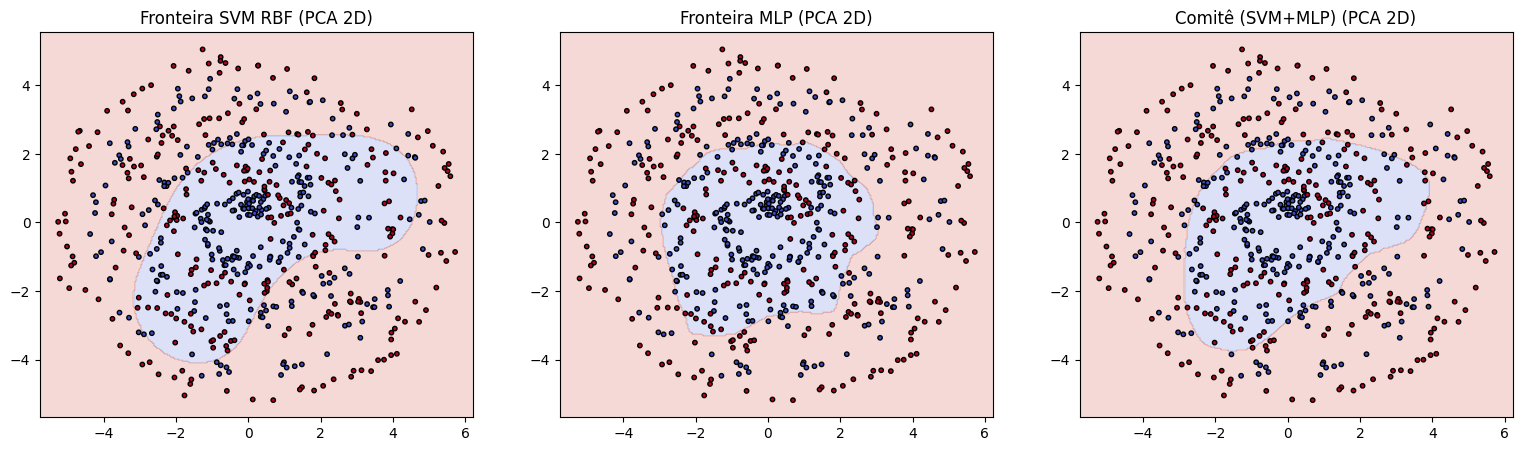

In [6]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
X_train_2d = pca.transform(X_train)
X_test_2d = pca.transform(X_test)

# Treinar classificadores nos dados 2D para visualização
svm_rbf_2d = SVC(kernel='rbf', probability=True, gamma='scale').fit(X_train_2d, y_train)
mlp_2d = MLPClassifier(hidden_layer_sizes=(40,), max_iter=2000, random_state=42).fit(X_train_2d, y_train)
committee_2d = VotingClassifier(estimators=[
    ('mlp', mlp_2d),
    ('svm', svm_rbf_2d)
], voting='soft').fit(X_train_2d, y_train)

fig, axs = plt.subplots(1, 3, figsize=(19, 5))
plot_decision_boundary(svm_rbf_2d, X_test_2d, y_test, axs[0], "Fronteira SVM RBF (PCA 2D)")
plot_decision_boundary(mlp_2d, X_test_2d, y_test, axs[1], "Fronteira MLP (PCA 2D)")
plot_decision_boundary(committee_2d, X_test_2d, y_test, axs[2], "Comitê (SVM+MLP) (PCA 2D)")
plt.show()